# Tutorial 2: Correlations

**Week 3, Day 5: Network Causality**

**By Neuromatch Academy**

**Content creators**: Ari Benjamin, Tony Liu, Konrad Kording

**Content reviewers**: Mike X Cohen, Madineh Sarvestani, Yoni Friedman, Ella Batty, Michael Waskom

**Production editors:** Gagana B, Spiros Chavlis

---
# Tutorial objectives

*Estimated timing of tutorial: 45 min*

This is Tutorial 2 on our day of examining causality. Below is the high level outline of what we'll cover today, with the sections we will focus on in this tutorial in bold:

1. Master definitions of causality
2. Understand that estimating causality is possible
3. Learn 4 different methods and understand when they fail
  - perturbations
  - **correlations**
  - simultaneous fitting/regression
  - instrumental variables

<br>

**Tutorial 2 objectives**

In Tutorial 1, we implemented and explored the dynamical system of neurons we will be working with throughout all of the tutorials today. We also learned about the "gold standard" of measuring causal effects through random perturbations. As random perturbations are often not possible, we will now turn to alternative methods to attempt to measure causality. We will:

- Learn how to estimate connectivity from observations assuming **correlations approximate causation**
- Show that this only works when the network is small

<br>

**Tutorial 2 setting**

Often, we can't force neural activities or brain areas to be on or off. We just have to observe. Maybe we can get the correlation between two nodes -- is that good enough? The question we ask in this tutorial is **when is correlation a "good enough" substitute for causation?**

The answer is not "never", actually, but "sometimes".

---
# Setup

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [3]:
# @title Plotting Functions

def see_neurons(A, ax, show=False):
  """
  Visualizes the connectivity matrix.

  Args:
      A (np.ndarray): the connectivity matrix of shape (n_neurons, n_neurons)
      ax (plt.axis): the matplotlib axis to display on

  Returns:
      Nothing, but visualizes A.
  """
  A = A.T  # make up for opposite connectivity
  n = len(A)
  ax.set_aspect('equal')
  thetas = np.linspace(0, np.pi * 2, n, endpoint=False)
  x, y = np.cos(thetas), np.sin(thetas),
  ax.scatter(x, y, c='k', s=150)
  A = A / A.max()
  for i in range(n):
    for j in range(n):
      if A[i, j] > 0:
        ax.arrow(x[i], y[i], x[j] - x[i], y[j] - y[i],
                 color='k', alpha=A[i, j], head_width=.15,
                 width = A[i,j] / 25, shape='right',
                 length_includes_head=True)
  ax.axis('off')
  if show:
    plt.show()


def plot_estimation_quality_vs_n_neurons(number_of_neurons):
  """
  A wrapper function that calculates correlation between true and estimated connectivity
  matrices for each number of neurons and plots

  Args:
    number_of_neurons (list): list of different number of neurons for modeling system
    corr_func (function): Function for computing correlation
  """
  corr_data = np.zeros((n_trials, len(number_of_neurons)))
  for trial in range(n_trials):
    print(f"simulating trial {trial + 1} of {n_trials}")
    for j, size in enumerate(number_of_neurons):
      corr = get_sys_corr(size, timesteps, trial)
      corr_data[trial, j] = corr

  corr_mean = corr_data.mean(axis=0)
  corr_std = corr_data.std(axis=0)

  plt.figure()
  plt.plot(number_of_neurons, corr_mean)
  plt.fill_between(number_of_neurons, corr_mean - corr_std,
                   corr_mean + corr_std, alpha=.2)
  plt.xlabel("Number of neurons")
  plt.ylabel("Correlation")
  plt.title("Similarity between A and R as a function of network size")
  plt.show()


def plot_connectivity_matrix(A, ax=None, show=False):
  """Plot the (weighted) connectivity matrix A as a heatmap

    Args:
      A (ndarray): connectivity matrix (n_neurons by n_neurons)
      ax: axis on which to display connectivity matrix
  """
  if ax is None:
    ax = plt.gca()
  lim = np.abs(A).max()
  im = ax.imshow(A, vmin=-lim, vmax=lim, cmap="coolwarm")
  ax.tick_params(labelsize=10)
  ax.xaxis.label.set_size(15)
  ax.yaxis.label.set_size(15)
  cbar = ax.figure.colorbar(im, ax=ax, ticks=[0], shrink=.7)
  cbar.ax.set_ylabel("Connectivity Strength", rotation=90,
                     labelpad=20, va="bottom")
  ax.set(xlabel="Connectivity from", ylabel="Connectivity to")
  if show:
    plt.show()


def plot_true_vs_estimated_connectivity(estimated_connectivity,
                                        true_connectivity,
                                        selected_neuron=None,
                                        correlation=None):
  """Visualize true vs estimated connectivity matrices

  Args:
    estimated_connectivity (ndarray): estimated connectivity (n_neurons by n_neurons)
    true_connectivity (ndarray): ground-truth connectivity (n_neurons by n_neurons)
    correlation (float): correlation between true and estimated connectivity
    selected_neuron (int or None): None if plotting all connectivity, otherwise connectivity
      from selected_neuron will be shown

  """
  fig, axs = plt.subplots(1, 2, figsize=(10, 5))

  if selected_neuron is not None:
    plot_connectivity_matrix(true_connectivity[:, [selected_neuron]], ax=axs[0])
    plot_connectivity_matrix(np.expand_dims(estimated_connectivity, axis=1),
                             ax=axs[1])
    axs[0].set_xticks([0])
    axs[1].set_xticks([0])
    axs[0].set_xticklabels([selected_neuron])
    axs[1].set_xticklabels([selected_neuron])
  else:
    plot_connectivity_matrix(true_connectivity, ax=axs[0])
    plot_connectivity_matrix(estimated_connectivity, ax=axs[1])

  axs[0].set(title="True connectivity matrix A")
  axs[1].set(title="Estimated connectivity matrix R")
  if correlation:
    fig.suptitle(f"Correlation between A and R: {correlation:.3f}")
  plt.show()

In [4]:
# @title Helper Functions

def sigmoid(x):
  """
  Compute sigmoid nonlinearity element-wise on x.

  Args:
    x (np.ndarray): the numpy data array we want to transform
  Returns
    (np.ndarray): x with sigmoid nonlinearity applied
  """
  return 1 / (1 + np.exp(-x))


def create_connectivity(n_neurons, random_state=42, p=0.9):
  """
  Generate our nxn causal connectivity matrix.

  Args:
    n_neurons (int): the number of neurons in our system.
    random_state (int): random seed for reproducibility

  Returns:
    A (np.ndarray): our 0.1 sparse connectivity matrix
  """
  np.random.seed(random_state)
  A_0 = np.random.choice([0, 1], size=(n_neurons, n_neurons), p=[p, 1 - p])

  # set the timescale of the dynamical system to about 100 steps
  _, s_vals, _ = np.linalg.svd(A_0)
  if s_vals[0] != 0 and not np.isnan(s_vals[0]):
    A = A_0 / (1.01 * s_vals[0])
  else:
    eps = 1e-12
    A = eps*np.ones_like(A_0)  # if denominator is zero, set A to a small value

  return A


def simulate_neurons(A, timesteps, random_state=42):
  """
  Simulates a dynamical system for the specified number of neurons and timesteps.

  Args:
    A (np.array): the connectivity matrix
    timesteps (int): the number of timesteps to simulate our system.
    random_state (int): random seed for reproducibility

  Returns:
    X has shape (n_neurons, timeteps).
  """
  np.random.seed(random_state)
  n_neurons = len(A)
  X = np.zeros((n_neurons, timesteps))

  for t in range(timesteps - 1):
    epsilon = np.random.multivariate_normal(np.zeros(n_neurons),
                                            np.eye(n_neurons))
    X[:, t + 1] = sigmoid(A.dot(X[:, t]) + epsilon)

  return X


def get_sys_corr(n_neurons, timesteps, random_state=42, neuron_idx=None):
  """
  A wrapper function for our correlation calculations between A and R.

  Args:
    n_neurons (int): the number of neurons in our system.
    timesteps (int): the number of timesteps to simulate our system.
    random_state (int): seed for reproducibility
    neuron_idx (int): optionally provide a neuron idx to slice out

  Returns:
    A single float correlation value representing the similarity between A and R
  """
  A = create_connectivity(n_neurons, random_state)
  X = simulate_neurons(A, timesteps)
  R = correlation_for_all_neurons(X)

  return np.corrcoef(A.flatten(), R.flatten())[0, 1]

The helper functions defined above are:

- `sigmoid`: computes sigmoid nonlinearity element-wise on input, from Tutorial 1.
- `create_connectivity`: generates nxn causal connectivity matrix, from Tutorial 1.
- `simulate_neurons`: simulates a dynamical system for the specified number of neurons and timesteps, from Tutorial 1.
- `get_sys_corr`: a wrapper function for correlation calculations between $A$ and $R$.

---
# Section 1: Small systems
### Video 1: Correlation vs causation
Video available at https://youtube.com/watch?v=vjBO-S7KNPI

## Coding Exercise 1: Try to approximate causation with correlation

In small systems, correlation can look like causation. Let's attempt to recover the true connectivity matrix ($A$) just by correlating the neural state at each timestep with the previous state: $C = \vec{x_t} \vec{x_{t+1}}^\top$.

Complete this function to estimate the connectivity matrix of a single neuron by calculating the correlation coefficients with every other neuron at the next timestep. That is, please correlate two vectors:
1. The activity of a selected neuron at time $t$
2. The activity of all other neurons at time $t+1$

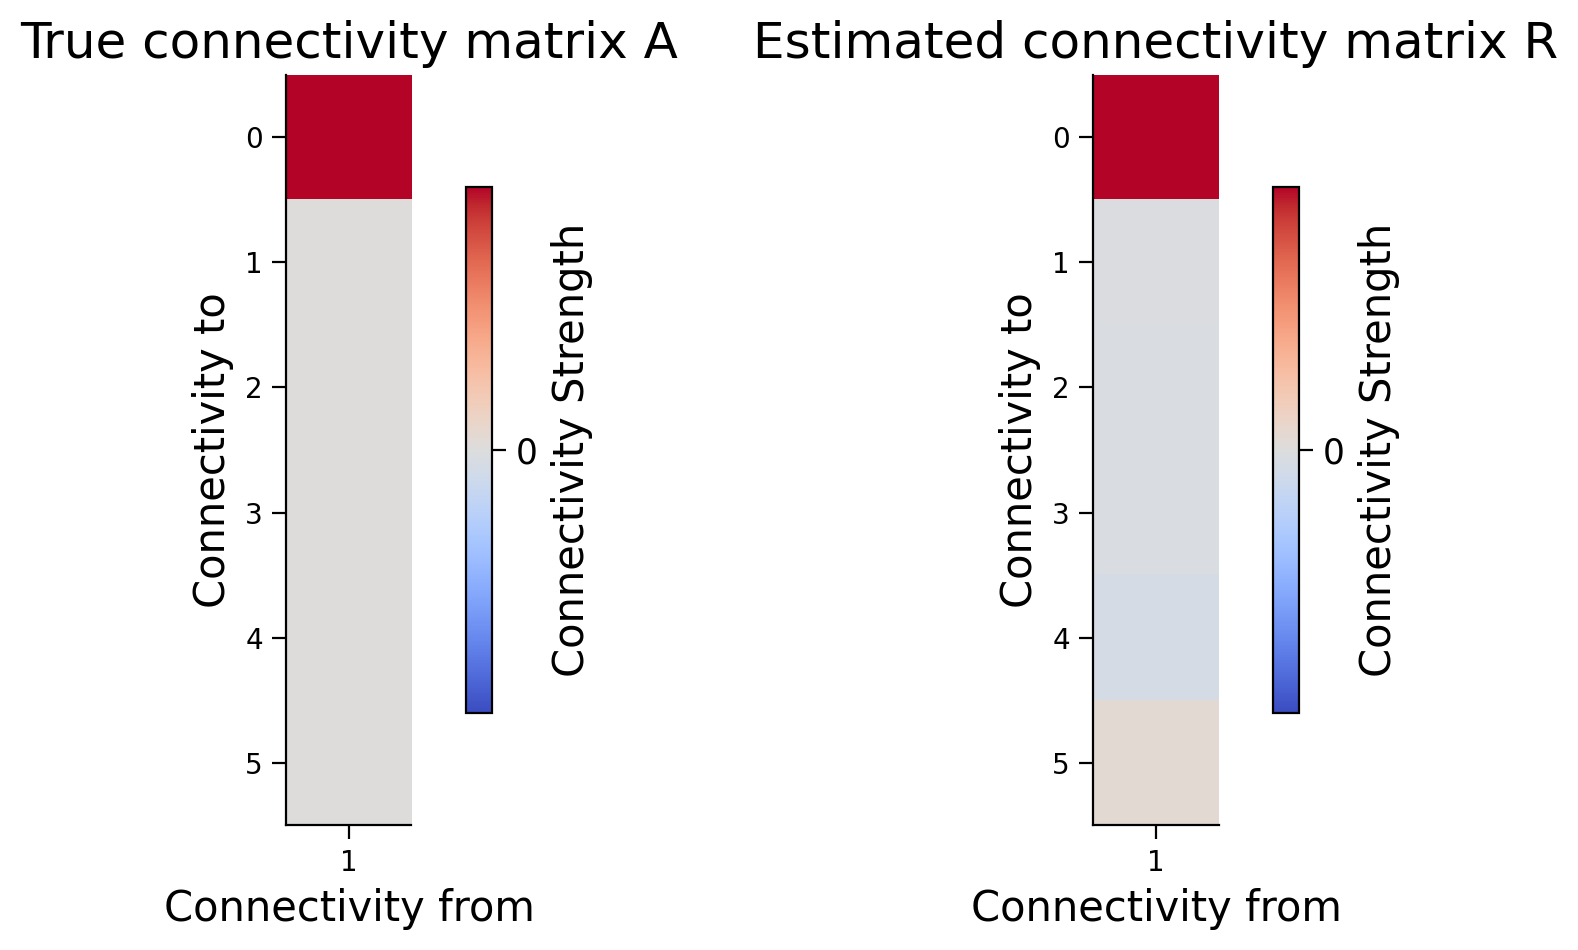

In [5]:
def compute_connectivity_from_single_neuron(X, selected_neuron):
  """
  Computes the connectivity matrix from a single neuron neurons using correlations

  Args:
      X (ndarray): the matrix of activities
      selected_neuron (int): the index of the selected neuron

  Returns:
      estimated_connectivity (ndarray): estimated connectivity for the selected neuron, of shape (n_neurons,)
  """

  # Extract the current activity of selected_neuron, t
  current_activity = X[selected_neuron, :-1]

  # Extract the observed outcomes of all the neurons
  next_activity = X[:, 1:]

  # Initialize estimated connectivity matrix
  estimated_connectivity = np.zeros(n_neurons)

  # Loop through all neurons
  for neuron_idx in range(n_neurons):

    # Get the activity of neuron_idx
    this_output_activity = next_activity[neuron_idx]

    ########################################################################
    ## TODO: Estimate the neural correlations between
    ## this_output_activity        and       current_activity
    ## -------------------                  ----------------
    ##
    ## Note that np.corrcoef returns the full correlation matrix; we want the
    ## top right corner, which we have already provided.
    ## FIll out function and remove
    # raise NotImplementedError('Compute neural correlations')
    ########################################################################
    # Compute correlation
    correlation = np.corrcoef(this_output_activity, current_activity)[0, 1]

    # Store this neuron's correlation
    estimated_connectivity[neuron_idx] = correlation

  return estimated_connectivity


# Simulate a 6 neuron system for 5000 timesteps again.
n_neurons = 6
timesteps = 5000
selected_neuron = 1

# Invoke a helper function that generates our nxn causal connectivity matrix
A = create_connectivity(n_neurons)

# Invoke a helper function that simulates the neural activity
X = simulate_neurons(A, timesteps)

# Estimate connectivity
estimated_connectivity = compute_connectivity_from_single_neuron(X, selected_neuron)

# Visualize
plot_true_vs_estimated_connectivity(estimated_connectivity, A, selected_neuron)

Hopefully you saw that it pretty much worked. We wrote a function that does what you just did but in matrix form, so it's a little faster. It also does all neurons at the same time (helper function `correlation_for_all_neurons`).

In [6]:
# @markdown Execute this cell get helper function `correlation_for_all_neurons`

def correlation_for_all_neurons(X):
  """Computes the connectivity matrix for the all neurons using correlations

    Args:
        X: the matrix of activities

    Returns:
        estimated_connectivity (np.ndarray): estimated connectivity for the selected neuron, of shape (n_neurons,)
  """
  n_neurons = len(X)
  S = np.concatenate([X[:, 1:], X[:, :-1]], axis=0)
  R = np.corrcoef(S)[:n_neurons, n_neurons:]
  return R

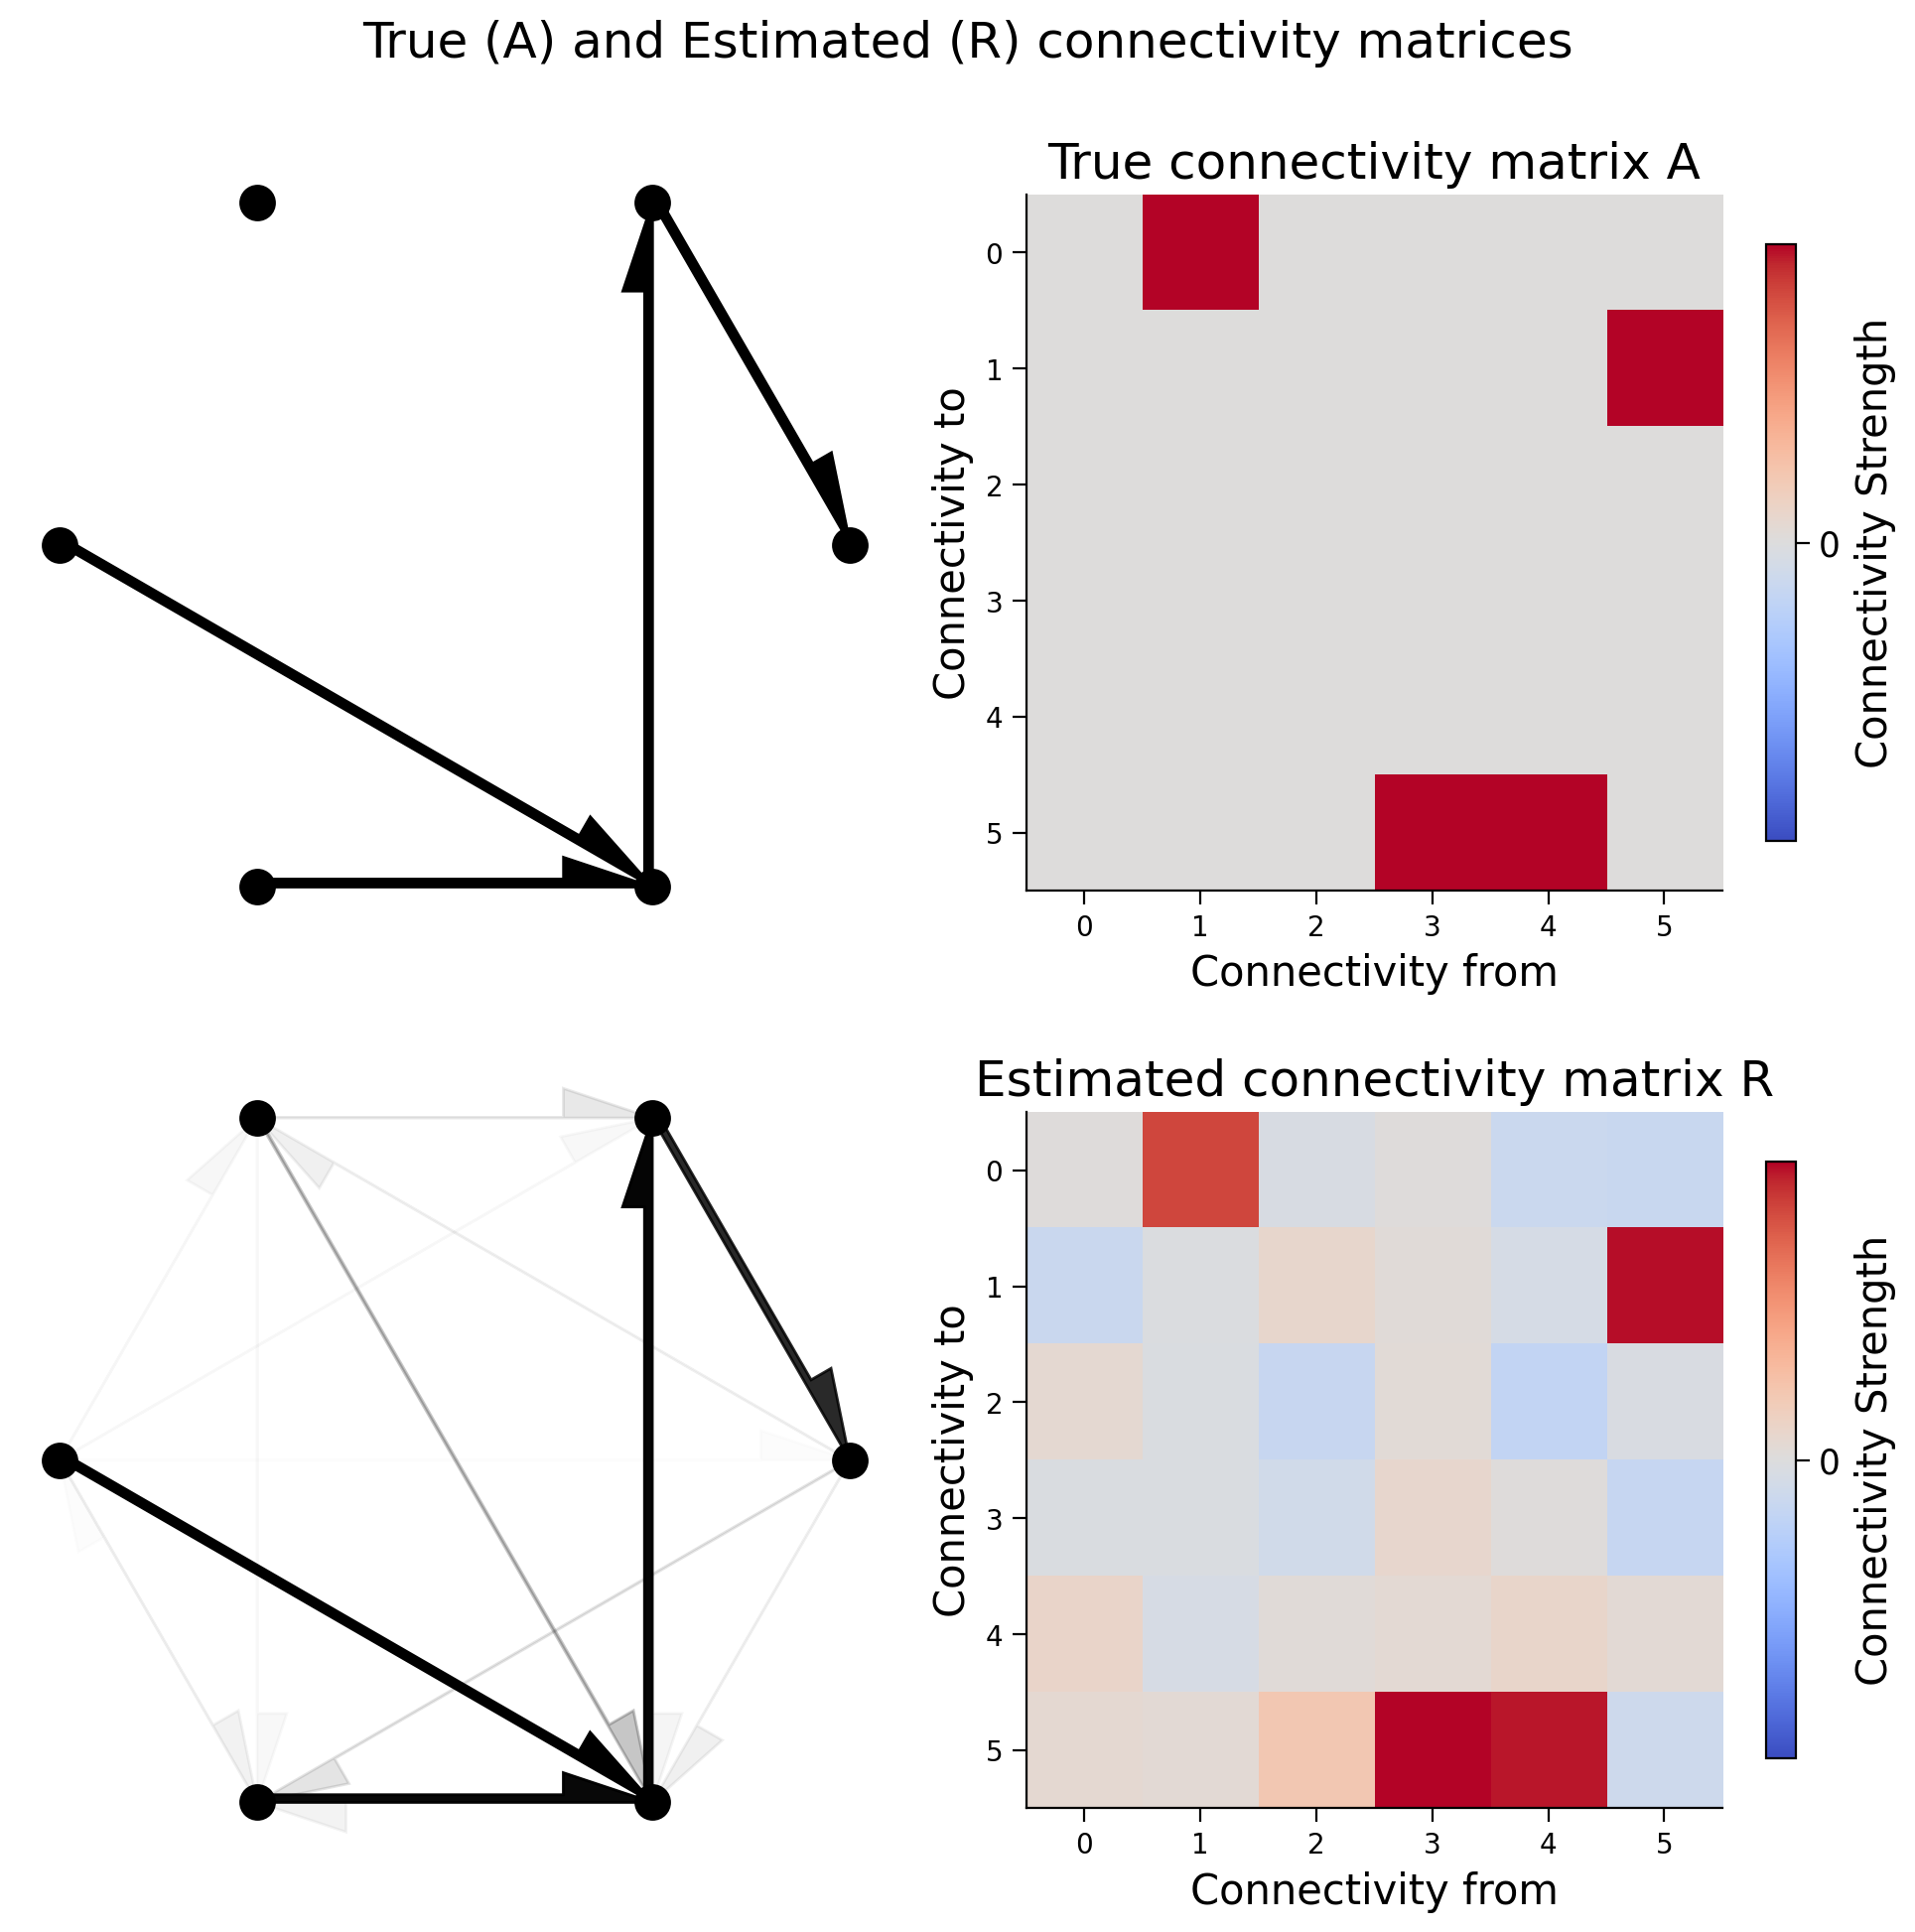

In [7]:
# @markdown Execute this cell to visualize full estimated vs true connectivity

R = correlation_for_all_neurons(X)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
see_neurons(A, axs[0, 0])
plot_connectivity_matrix(A, ax=axs[0, 1])
axs[0, 1].set_title("True connectivity matrix A")

see_neurons(R, axs[1, 0])
plot_connectivity_matrix(R, ax=axs[1, 1])
axs[1, 1].set_title("Estimated connectivity matrix R")

fig.suptitle("True (A) and Estimated (R) connectivity matrices")

plt.tight_layout()
plt.show()

That pretty much worked too. Let's quantify how much it worked.

We'll calculate the correlation coefficient between the true connectivity and the actual connectivity;

In [8]:
print(f"Correlation matrix of A and R: {np.corrcoef(A.flatten(), R.flatten())[0, 1]:.5f}")

Correlation matrix of A and R: 0.95967


It *appears* in our system that correlation captures causality.

### Video 2: Correlation ~ causation for small systems
Video available at https://youtube.com/watch?v=eWLOnTUe9SM

**Video correction**: the connectivity graph plots and associated explanations in this and other videos show the wrong direction of connectivity (the arrows should be pointing the opposite direction). This has been fixed in the figures above.

---
# Section 2: Large systems

As our system becomes more complex however, correlation fails to capture causality.

## Section 2.1: Failure of correlation in complex systems

Let's jump to a much bigger system. Instead of 6 neurons, we will now use 100 neurons. How does the estimation quality of the connectivity matrix change?

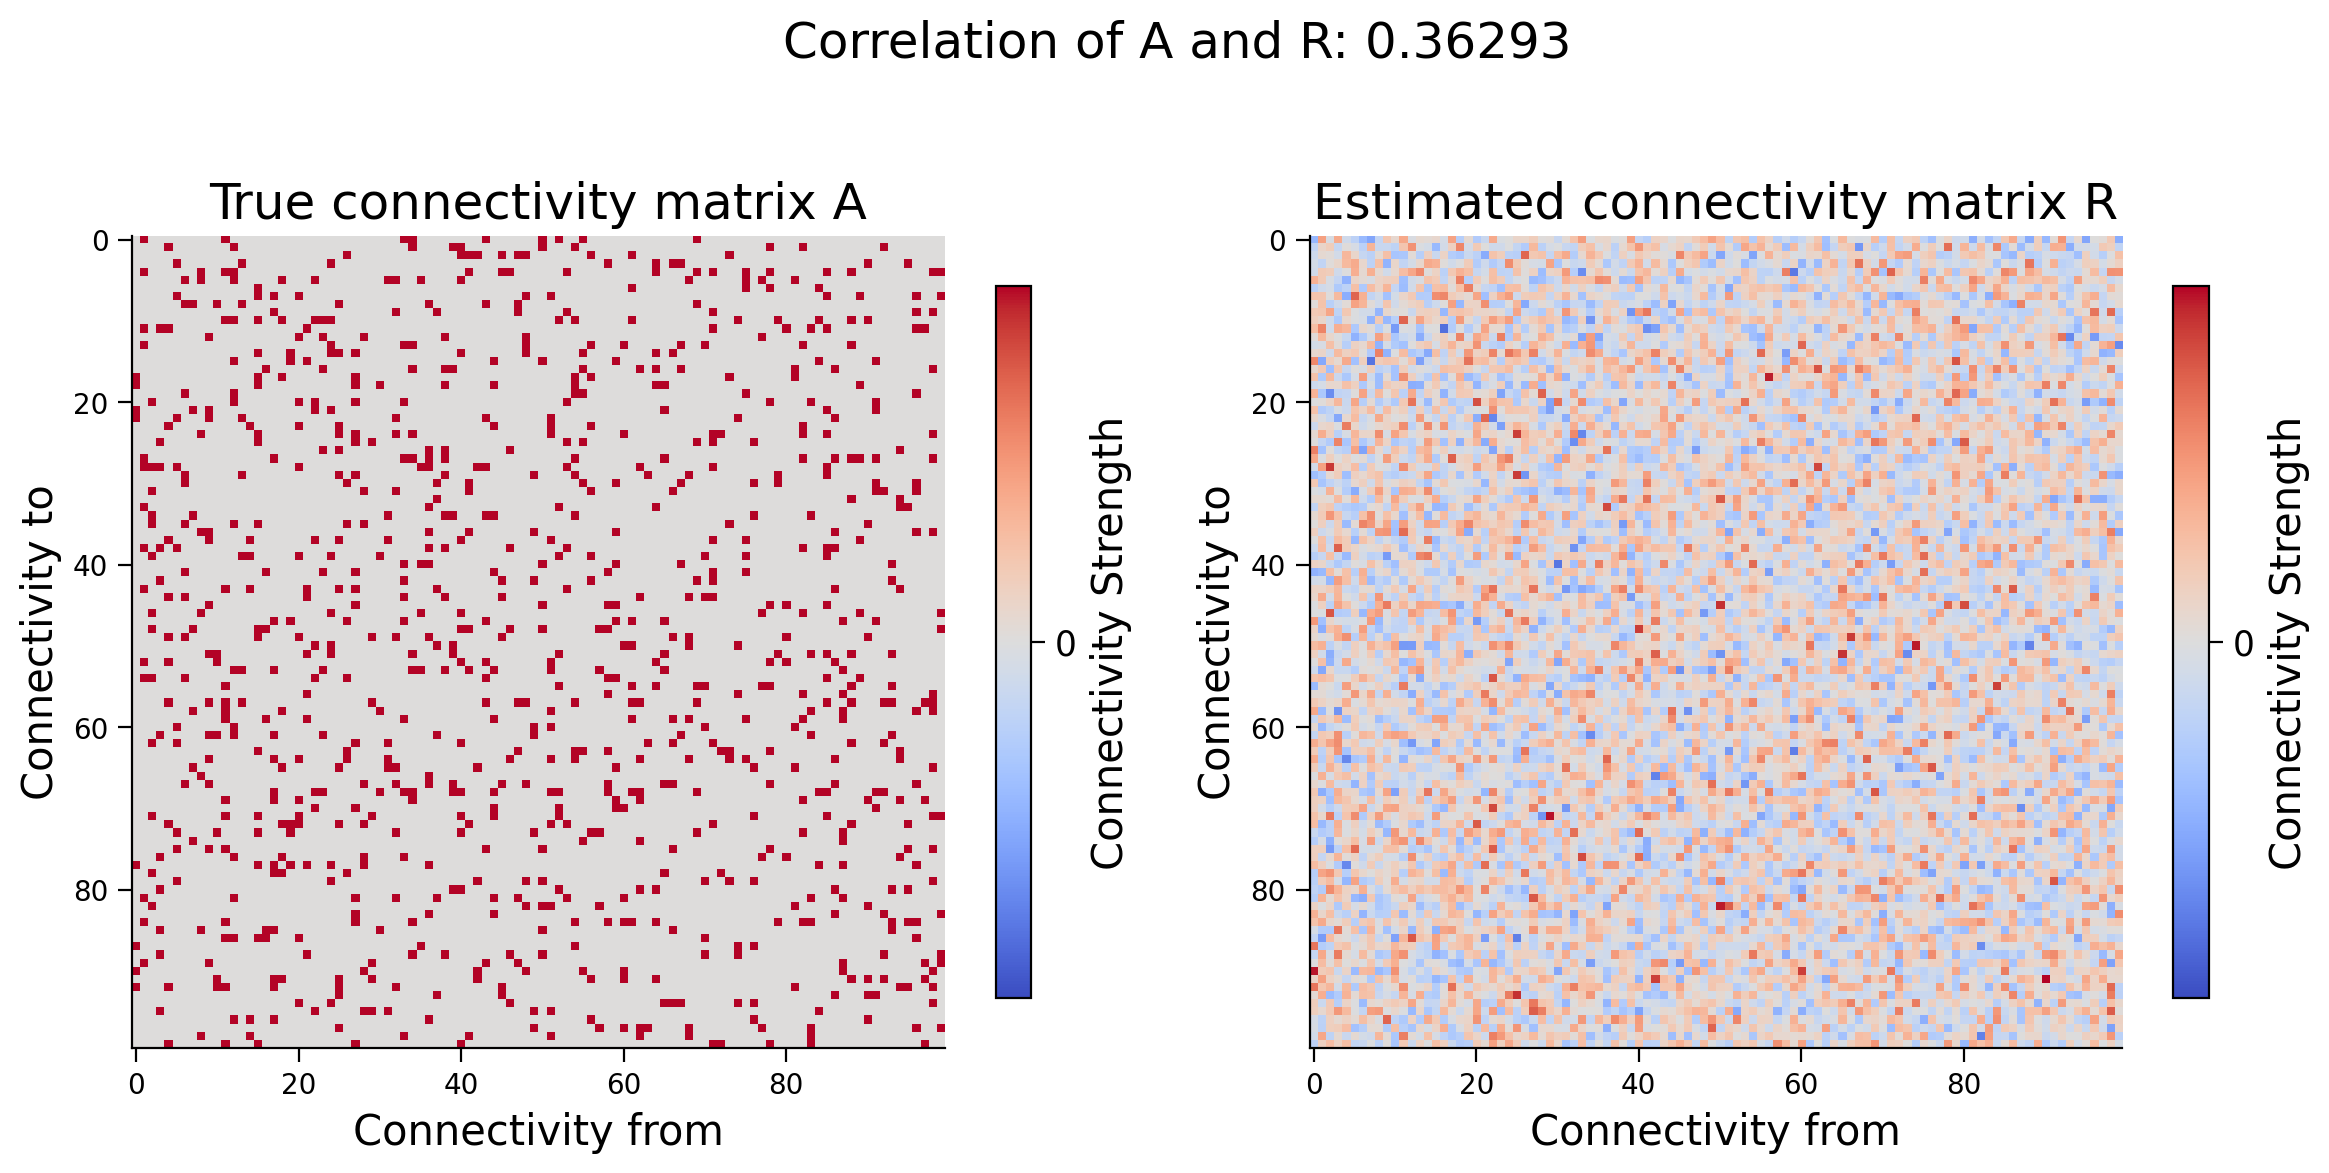

In [10]:
# @markdown Execute this cell to simulate large system, estimate connectivity matrix with correlation and return estimation quality

# Simulate a 100 neuron system for 5000 timesteps.
n_neurons = 100
timesteps = 5000
random_state = 42

A = create_connectivity(n_neurons, random_state)
X = simulate_neurons(A, timesteps)
R = correlation_for_all_neurons(X)
corr = np.corrcoef(A.flatten(), R.flatten())[0, 1]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plot_connectivity_matrix(A, ax=axs[0])
axs[0].set_title("True connectivity matrix A")
plot_connectivity_matrix(R, ax=axs[1])
axs[1].set_title("Estimated connectivity matrix R")
fig.suptitle(f"Correlation of A and R: {corr:.5f}")
fig.tight_layout()
plt.show()

### Video 3: Correlation vs causation in large systems
Video available at https://youtube.com/watch?v=U4sV-7g8T08

## Section 2.2: Correlation as a function of network size

### Interactive Demo 2.2.1: Connectivity estimation as a function of number of neurons

Instead of looking at just a few neurons (6) or a lot of neurons (100), as above, we will now systematically vary the number of neurons and plot the resulting changes in correlation coefficient between the true and estimated connectivity matrices.

In [11]:
# @markdown Execute this cell to enable the widget
@widgets.interact(n_neurons=(6, 42, 3))
def plot_corrs(n_neurons=6):
  fig, axs = plt.subplots(1, 2, figsize=(10, 5))
  timesteps = 2000
  random_state = 42
  A = create_connectivity(n_neurons, random_state)
  X = simulate_neurons(A, timesteps)
  R = correlation_for_all_neurons(X)
  corr = np.corrcoef(A.flatten(), R.flatten())[0, 1]
  plot_connectivity_matrix(A, ax=axs[0])
  plot_connectivity_matrix(R, ax=axs[1])
  axs[0].set_title("True connectivity matrix A")
  axs[1].set_title("Estimated connectivity matrix R")
  fig.suptitle(f"Correlation of A and R: {corr:.2f}")
  plt.show()

interactive(children=(IntSlider(value=6, description='n_neurons', max=42, min=6, step=3), Output()), _dom_clas…

Of course there is some variability due to randomness in $A$. Let's average over a few trials and find the relationship.

simulating trial 1 of 5
simulating trial 2 of 5
simulating trial 3 of 5


C:\Users\gstju\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\gstju\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


simulating trial 4 of 5
simulating trial 5 of 5


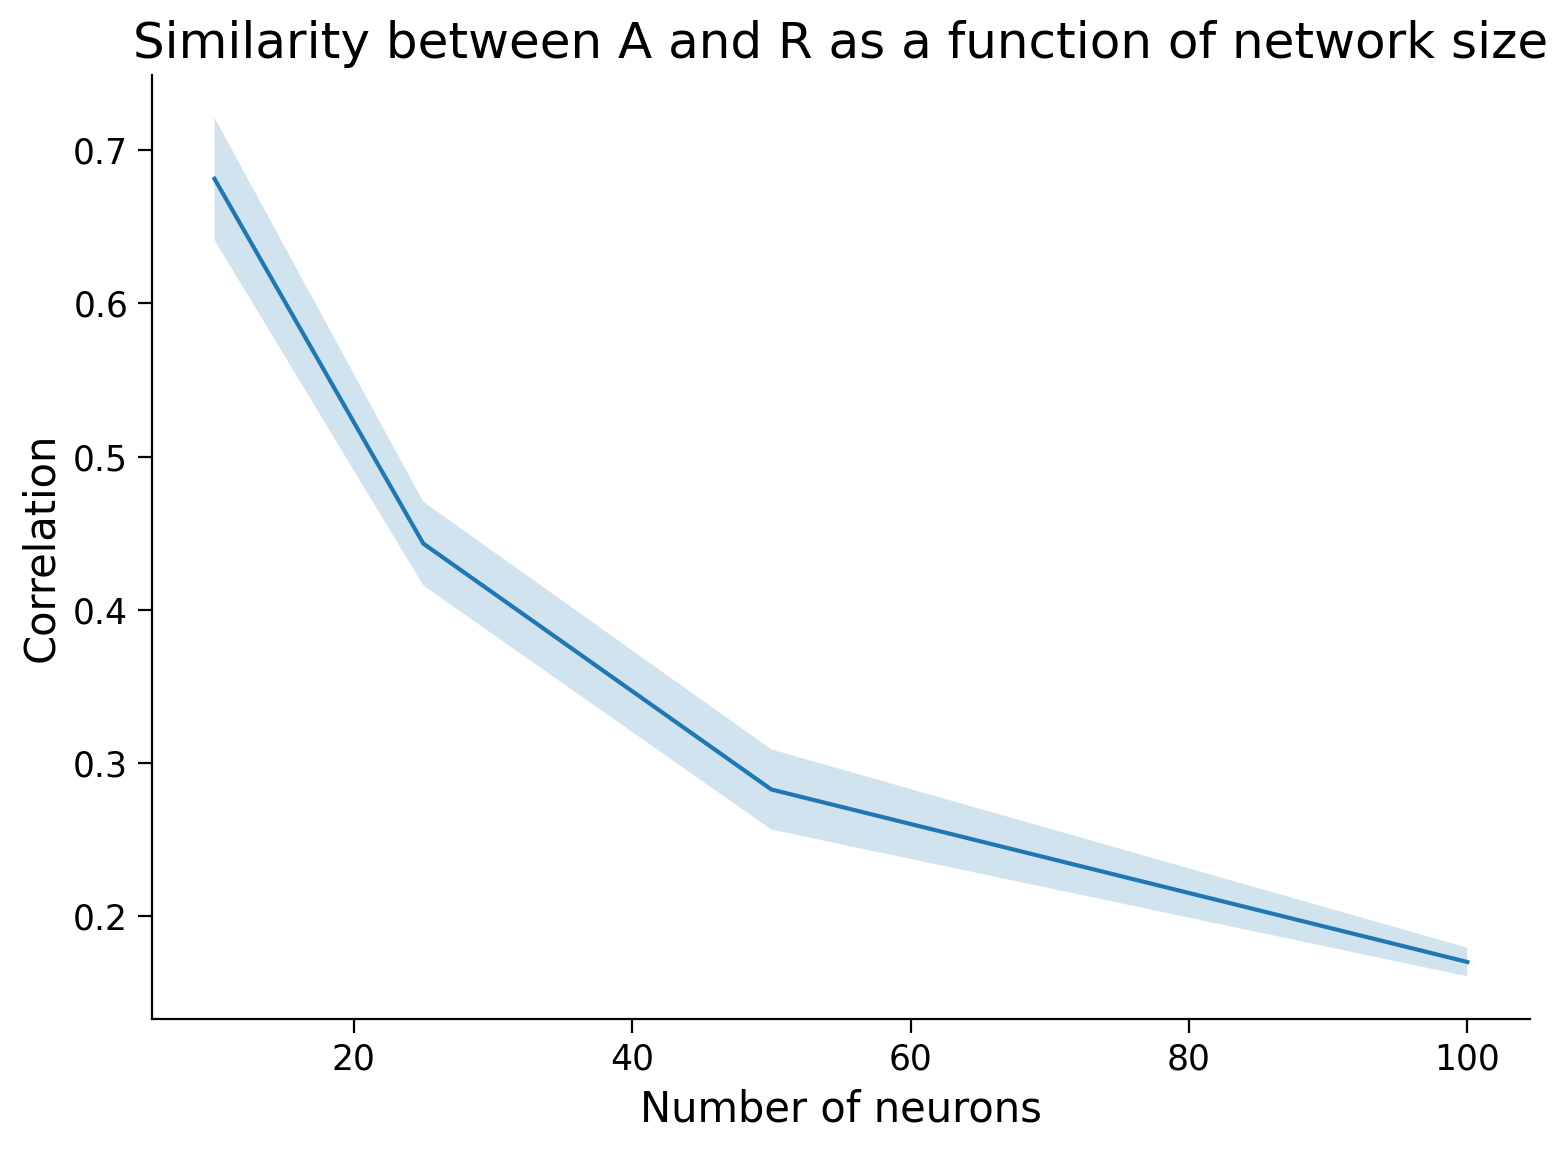

In [12]:
# @markdown Execute this cell to plot connectivity estimation as a function of network size

n_trials = 5
timesteps = 1000  # shorter timesteps for faster running time
number_of_neurons = [5, 10, 25, 50, 100]
plot_estimation_quality_vs_n_neurons(number_of_neurons)

### Interactive Demo 2.2.2: Connectivity estimation as a function of the sparsity of $A$

You may rightly wonder if correlation only fails for large systems for certain types of $A$. In this interactive demo, you can examine connectivity estimation as a function of the sparsity of $A$. Does connectivity estimation get better or worse with less sparsity?

---
# Section 3: Reflecting on causality


 ## Think! 3: Reflecting on causality

Please discuss the following questions within groups for around 10 minutes.

* Think of a research paper you've written. Did it use previous causal knowledge (e.g. a mechanism), or ask a causal question? Try phrasing that causal relationship in the language of an intervention. ("*If I were to force $A$ to be $A'$, $B$ would...*")
* What methods for interventions exist in your area of neuroscience?
* Think about these common "filler" words. Do they imply a causal relationship, in its interventional definition? (*regulates, mediates, generates, modulates, shapes, underlies, produces, encodes, induces, enables, ensures, supports, promotes, determines*)
* What dimensionality would you (very roughly) estimate the brain to be? Would you expect correlations between neurons to give you their connectivity? Why?

---
# Summary

### Video 4: Summary

Video available at https://youtube.com/watch?v=hRyAN3yak_U

Now for the takeaway. We know that for large systems correlation ≠ causation. But what about when we coarsely sample the large system? Do we get better at estimating the *effective* causal interaction between groups (=average of weights) from the correlation between the groups?

From our simulation above, the answer appears to be no: as the number of neurons per group increases, we don't see any significant increase in our ability to estimate the causal interaction between groups.

If you have time after completing all tutorials and are interested, please see Bonus Section 1 below for a brief discussion of correlation as a similarity metric and Bonus Section 2 to learn about causality and correlation in low resolution systems.